In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [2]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

In [3]:
batch_size = 128
latent_dim = 32
vae_epochs = 5
diff_epochs = 20
lr_vae=1e-3
T=100
lr_diff=1e-3

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: mps


In [4]:
from pathlib import Path

root_dir = Path('/Users/chris/Desktop/data')
if not root_dir.exists():
    root_dir = Path('/tmp/mnist_data')
    root_dir.mkdir(parents=True, exist_ok=True)

transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.MNIST(root=str(root_dir), train=True, download=False, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

print(f"MNIST train samples: {len(train_dataset)}")
print(f"Data root: {root_dir}")

MNIST train samples: 60000
Data root: /Users/chris/Desktop/data


In [5]:
#定义VAE模型
class VAE(nn.Module):
    def __init__(self, input_dim=784, latent_dim=32):
        super(VAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 2 * latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 400),
            nn.ReLU(),
            nn.Linear(400, input_dim),
            nn.Sigmoid()
        )
    def encode(self, x):
        h = self.encoder(x)
        mu, log_var = torch.chunk(h, 2, dim=1)
        z = self.reparameterize(mu, log_var)
        return z , mu, log_var

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        z, mu, log_var = self.encode(x)
        x_recon = self.decoder(z)
        return x_recon, mu, log_var

model_VAE=VAE(input_dim=784, latent_dim=latent_dim).to(device)
optimizer_VAE = optim.Adam(model_VAE.parameters(), lr=lr_vae)

def vae_loss_function(x_recon, x, mu, log_var):
    recon_loss = F.binary_cross_entropy(x_recon, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return recon_loss + kl_loss,recon_loss,kl_loss
    

In [6]:
for epoch in range(vae_epochs):
    model_VAE.train()
    train_loss = 0

    for imgs, _ in train_loader:
        x = imgs.view(-1,784).to(device)
        optimizer_VAE.zero_grad()
        
        x_recon, mu, log_var = model_VAE(x)
        loss, recon_loss, kl_loss = vae_loss_function(x_recon, x, mu, log_var)

        loss.backward()
        train_loss += loss.item()
        optimizer_VAE.step()

    avg_loss = train_loss / len(train_dataset)
    print(f"Epoch [{epoch + 1}/{vae_epochs}], Loss: {avg_loss:.4f}, Recon Loss: {recon_loss.item():.4f}, KL Loss: {kl_loss.item():.4f}")

Epoch [1/5], Loss: 166.5535, Recon Loss: 10365.2676, KL Loss: 2087.2000
Epoch [2/5], Loss: 123.7291, Recon Loss: 8848.8916, KL Loss: 2385.5115
Epoch [3/5], Loss: 115.8590, Recon Loss: 8157.8252, KL Loss: 2410.4116
Epoch [4/5], Loss: 112.2588, Recon Loss: 7965.4238, KL Loss: 2591.4717
Epoch [5/5], Loss: 110.1979, Recon Loss: 7745.2197, KL Loss: 2520.6792


In [7]:
betas=torch.linspace(1e-4,0.02,T).to(device)
alphas = 1- betas
alpha_bars = torch.cumprod(alphas,dim=0)

print("beta scedule ready")

beta scedule ready


In [13]:
# 定义潜空间扩散模型类
class LatentDiffusion(nn.Module):
    # 初始化模型结构和扩散参数
    def __init__(self, latent_dim, timesteps=T):
        super().__init__()
        self.latent_dim = latent_dim
        self.timesteps = timesteps

        # 将潜变量视作长度为 latent_dim 的一维序列，构建带跳跃连接的 U-Net
        self.enc1 = nn.Sequential(
            nn.Conv1d(2, 64, kernel_size=3, padding=1),
            nn.GroupNorm(8, 64),
            nn.SiLU(),
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.GroupNorm(8, 64),
            nn.SiLU(),
        )
        self.down = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.GroupNorm(8, 128),
            nn.SiLU(),
        )
        self.mid = nn.Sequential(
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.GroupNorm(8, 128),
            nn.SiLU(),
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.GroupNorm(8, 128),
            nn.SiLU(),
        )
        self.up = nn.Sequential(
            nn.ConvTranspose1d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.GroupNorm(8, 64),
            nn.SiLU(),
        )
        self.out = nn.Sequential(
            nn.Conv1d(128, 64, kernel_size=3, padding=1),
            nn.GroupNorm(8, 64),
            nn.SiLU(),
            nn.Conv1d(64, 1, kernel_size=1),
        )

    # 定义模型的前向传播过程
    def forward(self, z_t, t):
        batch_size = z_t.size(0)
        t_input = (t.float() / self.timesteps).view(batch_size, 1, 1)
        t_channel = t_input.expand(-1, 1, self.latent_dim)
        x = torch.cat([z_t.unsqueeze(1), t_channel], dim=1)

        skip = self.enc1(x)
        x = self.down(skip)
        x = self.mid(x)
        x = self.up(x)
        x = F.interpolate(x, size=skip.size(-1), mode="linear", align_corners=False)
        return self.out(torch.cat([x, skip], dim=1)).squeeze(1)

# 创建潜空间扩散模型并移动到指定设备
diff_model = LatentDiffusion(latent_dim=latent_dim, timesteps=T).to(device)
# 创建 Adam 优化器
optimizer_diff = optim.Adam(diff_model.parameters(), lr=lr_diff)

In [14]:
# 遍历所有扩散模型训练轮次
for epoch in range(diff_epochs):
    # 切换到训练模式
    diff_model.train()
    # 初始化当前轮次的累计损失
    train_loss = 0.0

    # 遍历训练数据加载器中的每个批次
    for imgs, _ in train_loader:
        # 获取当前批次的图像数量
        batch_size_now = imgs.size(0)
        # 将图像展平为 784 维向量并移动到计算设备
        x = imgs.view(batch_size_now, 784).to(device)

        # 编码 VAE 时不计算梯度，因为 VAE 已经训练完成
        with torch.no_grad():
            # 将图像编码为原始潜变量 z0
            z0, _, _ = model_VAE.encode(x)

        # 为批次中的每个样本随机选择一个扩散时间步
        t = torch.randint(0, T, (batch_size_now,), device=device)
        # 创建与原始潜变量形状相同的高斯噪声
        eps = torch.randn_like(z0)

        # 取出每个样本对应时间步的累计 alpha 值
        alpha_bar_t = alpha_bars[t].view(-1, 1)
        # 按前向扩散公式将噪声添加到原始潜变量
        z_t = torch.sqrt(alpha_bar_t) * z0 + torch.sqrt(1 - alpha_bar_t) * eps

        # 根据带噪潜变量和时间步预测噪声
        pred_eps = diff_model(z_t, t)
        # 使用均方误差比较预测噪声和真实噪声
        loss = F.mse_loss(pred_eps, eps)

        # 清空上一次迭代累积的梯度
        optimizer_diff.zero_grad()
        # 计算当前损失对模型参数的梯度
        loss.backward()
        # 根据梯度更新模型参数
        optimizer_diff.step()

        # 累加当前批次的损失
        train_loss += loss.item()

    # 计算当前轮次的平均批次损失
    avg_loss = train_loss / len(train_loader)
    # 输出当前轮次和平均损失
    print(f"Epoch [{epoch+1}/{diff_epochs}], Loss: {avg_loss:.4f}")

Epoch [1/20], Loss: 0.7604
Epoch [2/20], Loss: 0.7531
Epoch [3/20], Loss: 0.7503
Epoch [4/20], Loss: 0.7502
Epoch [5/20], Loss: 0.7497
Epoch [6/20], Loss: 0.7471
Epoch [7/20], Loss: 0.7478
Epoch [8/20], Loss: 0.7451
Epoch [9/20], Loss: 0.7436
Epoch [10/20], Loss: 0.7418
Epoch [11/20], Loss: 0.7433
Epoch [12/20], Loss: 0.7438
Epoch [13/20], Loss: 0.7409
Epoch [14/20], Loss: 0.7399
Epoch [15/20], Loss: 0.7373
Epoch [16/20], Loss: 0.7396
Epoch [17/20], Loss: 0.7389
Epoch [18/20], Loss: 0.7391
Epoch [19/20], Loss: 0.7387
Epoch [20/20], Loss: 0.7352


In [15]:
# 禁用梯度计算，减少生成阶段的内存和计算开销
@torch.no_grad()
# 定义潜空间扩散采样函数
def sample_latent_diffusion(diff_model, VAE, n_samples=16):
    # 从标准正态分布采样初始潜变量
    z = torch.randn(n_samples, latent_dim, device=device)

    # 按时间步从 T-1 反向迭代到 0
    for t in reversed(range(T)):
        # 创建当前批次对应的时间步张量
        t_tensor = torch.full((n_samples,), t, device=device, dtype=torch.long)
        # 使用扩散模型预测当前潜变量中的噪声
        pred_eps = diff_model(z, t_tensor)

        # 获取当前时间步的 alpha 值
        alpha_t = alphas[t]
        # 获取当前时间步的累计 alpha 值
        alpha_bar_t = alpha_bars[t]

        # 根据 DDPM 公式计算反向过程的均值
        mean = (z - ((1 - alpha_t) / torch.sqrt(1 - alpha_bar_t)) * pred_eps) / torch.sqrt(alpha_t)

        # 如果还没有到最后一步，就加入随机噪声
        if t > 0:
            # 获取前一个时间步的累计 alpha 值
            alpha_bar_prev = alpha_bars[t - 1]
            # 生成与当前潜变量形状相同的随机噪声
            noise = torch.randn_like(z)
            # 得到下一个反向去噪状态
            z = mean + torch.sqrt(1 - alpha_bar_prev) * noise
        else:
            # 在最后一步直接使用去噪均值
            z = mean

    # 使用 VAE 解码器将潜变量还原为图像向量
    gen_imgs = VAE.decoder(z)
    # 将图像向量变为 batch_size x channel x height x width
    gen_imgs = gen_imgs.view(-1, 1, 28, 28)
    # 移动到 CPU，方便后续使用 matplotlib 显示
    gen_imgs = gen_imgs.cpu()
    # 返回生成的图像
    return gen_imgs

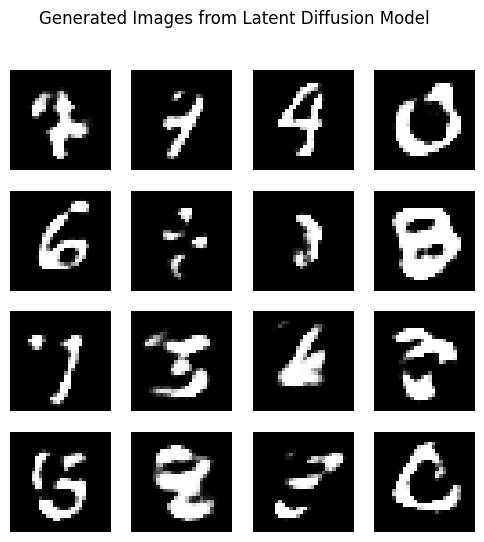

In [17]:
# 将 VAE 切换到评估模式
model_VAE.eval()
# 将扩散模型切换到评估模式
diff_model.eval()

# 禁用梯度计算并生成 16 张图像
with torch.no_grad():
    # 调用潜空间扩散采样函数
    generated = sample_latent_diffusion(diff_model, model_VAE, n_samples=16)

# 创建一个 6 x 6 英寸的画布
plt.figure(figsize=(6,6))
# 遍历 16 张生成图像
for i in range(16):
    # 在 4 x 4 网格中选择第 i+1 个子图
    plt.subplot(4,4,i+1)
    # 去掉单通道维度，将形状从 1 x 28 x 28 变为 28 x 28
    plt.imshow(generated[i].squeeze(0), cmap='gray')
    # 隐藏坐标轴
    plt.axis('off')
# 设置整张图的标题
plt.suptitle("Generated Images from Latent Diffusion Model")
# 显示生成结果
plt.show()